# Mutual Fund Analytics Capstone Project

# Performance Analytics

Intern: Chirag Nagra

Company: Bluestock Fintech MJ28

Project: Mutual Fund Analytics

Date: 05 June 2026

In [293]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [294]:
DATA = Path("../data/processed")

nav = pd.read_csv(DATA / "nav_history_clean.csv")
perf = pd.read_csv(DATA / "scheme_performance_clean.csv")
benchmark = pd.read_csv(DATA / "benchmark_indices_clean.csv")

print("NAV Shape:", nav.shape)
print("Performance Shape:", perf.shape)
print("Benchmark Shape:", benchmark.shape)

NAV Shape: (46000, 3)
Performance Shape: (40, 19)
Benchmark Shape: (8050, 3)


In [295]:
print(benchmark.columns)

print("\nUnique Indices:\n")

print(benchmark["index_name"].unique())

Index(['date', 'index_name', 'close_value'], dtype='str')

Unique Indices:

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [296]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [297]:
nav[["amfi_code","date","nav","daily_return"]].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


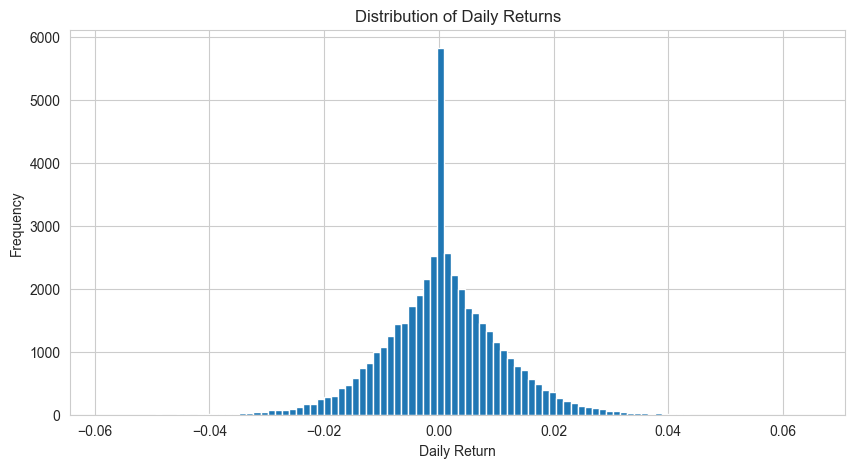

In [298]:
plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [299]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

### Insight 1

The distribution of daily returns is approximately centered around zero with a slight positive mean return (0.063% per day). Most observations fall within a narrow range, indicating stable day-to-day NAV movements, while occasional extreme gains and losses reflect market volatility.

In [300]:
nav["date"].min(), nav["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [301]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [302]:
latest_date = nav["date"].max()

cagr_results = []

for code in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == code].sort_values("date")

    latest_nav = fund_data.iloc[-1]["nav"]

    row = {"amfi_code": code}

    for years in [1, 3]:

        target_date = latest_date - pd.DateOffset(years=years)

        historical = fund_data[
            fund_data["date"] <= target_date
        ]

        if len(historical) > 0:

            start_nav = historical.iloc[-1]["nav"]

            row[f"CAGR_{years}Y"] = calculate_cagr(
                start_nav,
                latest_nav,
                years
            )

        else:
            row[f"CAGR_{years}Y"] = np.nan

    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y
0,100016,-2.224271,1.292649
1,100025,3.704969,3.916390
2,100033,53.232396,32.442459
3,101206,47.924120,28.967695
4,101207,-23.986032,-4.152381


In [303]:
cagr_df = cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
)

cagr_df.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y
16,119094,22.261065,35.111802
34,148567,20.360678,34.000916
24,120504,13.064279,32.487429
2,100033,53.232396,32.442459
25,120505,29.604659,31.777537
19,119551,60.437341,30.456524
30,120843,26.657082,29.582770
36,148569,39.751761,29.178902
3,101206,47.924120,28.967695
39,149324,65.138719,27.000427


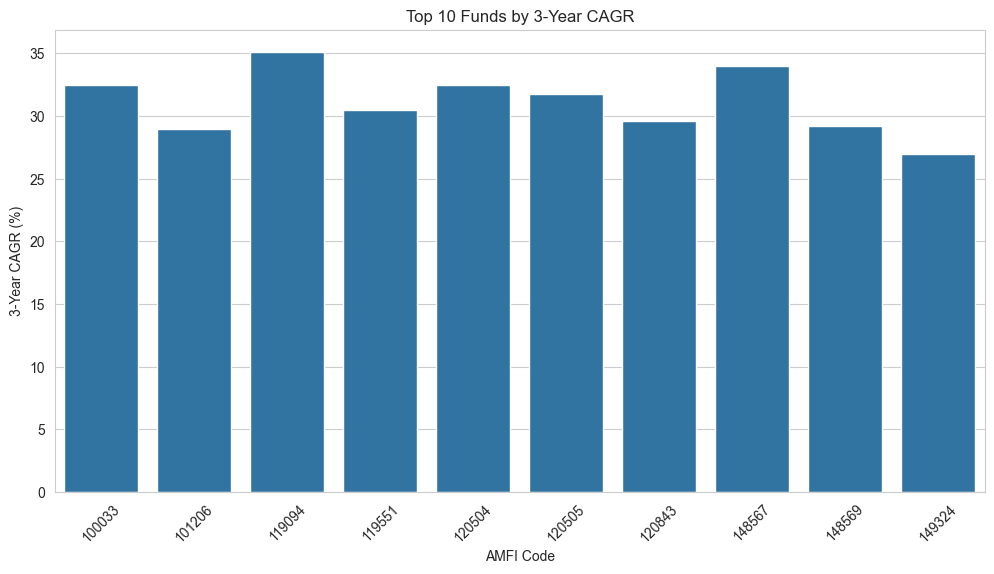

In [304]:
top10 = cagr_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="CAGR_3Y"
)

plt.title("Top 10 Funds by 3-Year CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("3-Year CAGR (%)")

plt.xticks(rotation=45)

plt.show()

### Insight 2

The top-performing mutual funds delivered strong 3-year CAGR values, indicating sustained wealth creation over the medium term. Growth-oriented equity schemes dominate the top rankings, significantly outperforming conservative debt-oriented funds.

In [305]:
rf = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    annual_return = returns.mean() * 252

    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - rf)
        / annual_volatility
    )

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "Sharpe_Ratio"]
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [306]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


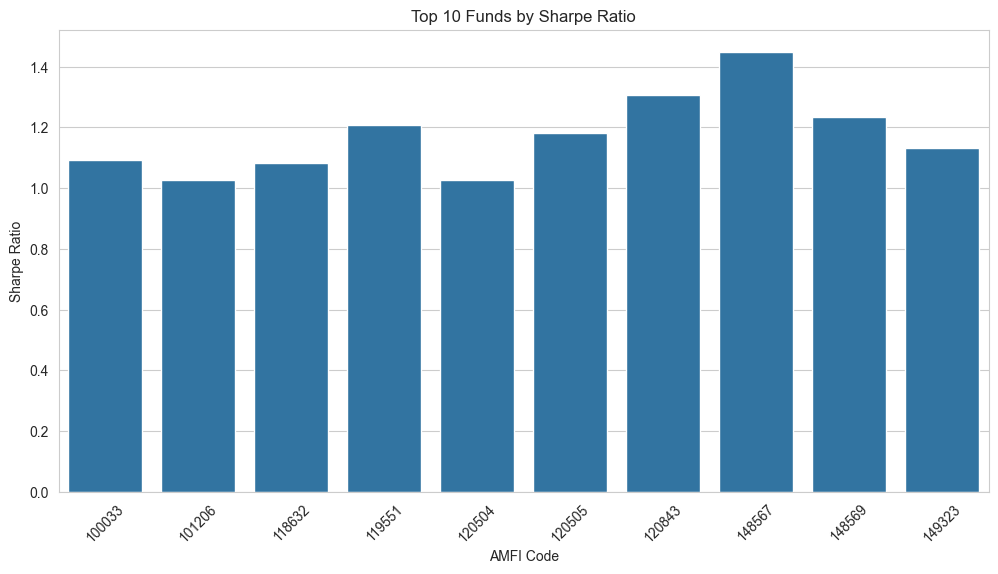

In [307]:
top10_sharpe = sharpe_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="amfi_code",
    y="Sharpe_Ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.show()

### Insight 3

Funds with the highest Sharpe Ratios generated superior risk-adjusted returns, indicating that investors were adequately compensated for the volatility they assumed. These schemes delivered the best balance between return and risk.

In [308]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio_rankings.csv",
    index=False
)

print("Sharpe rankings saved.")

Sharpe rankings saved.


In [309]:
sortino_results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    annual_return = returns.mean() * 252

    downside_returns = returns[
        returns < 0
    ]

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino = (
        (annual_return - rf)
        / downside_std
    )

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "Sortino_Ratio"]
)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [310]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


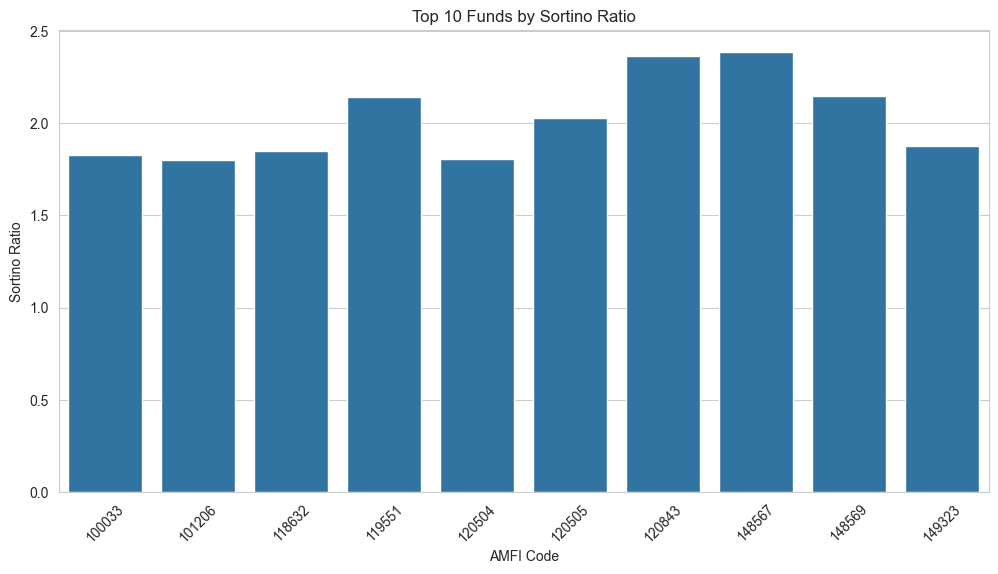

In [311]:
top10_sortino = sortino_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sortino,
    x="amfi_code",
    y="Sortino_Ratio"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.show()

### Insight 4

The highest-ranked funds achieved strong Sortino Ratios, demonstrating superior returns while effectively controlling downside risk. These schemes were particularly resilient during negative market periods.

In [312]:
sortino_df.to_csv(
    "../reports/sortino_ratio_rankings.csv",
    index=False
)

print("Sortino rankings saved.")

Sortino rankings saved.


In [313]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [314]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [315]:
nifty100[
    ["date","close_value","benchmark_return"]
].head(10)

,date,close_value,benchmark_return
1150,2022-01-03,17778.24,NaN
1151,2022-01-04,17537.52,-0.013540
1152,2022-01-05,17607.73,0.004003
1153,2022-01-06,17556.05,-0.002935
1154,2022-01-07,17664.02,0.006150
1155,2022-01-10,17516.51,-0.008351
1156,2022-01-11,17603.08,0.004942
1157,2022-01-12,17763.76,0.009128
1158,2022-01-13,17830.30,0.003746
1159,2022-01-14,17578.93,-0.014098


In [316]:
from scipy.stats import linregress

In [317]:
alpha_beta_results = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 100:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta_results.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [318]:
alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
).head(10)

,amfi_code,Alpha,Beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830
2,100033,0.271954,0.005104
34,148567,0.269838,0.023684
38,149323,0.265986,-0.002523
16,119094,0.260767,-0.066265
19,119551,0.232010,-0.031751


In [319]:
alpha_beta_df.sort_values(
    "Beta",
    ascending=False
).head(10)

,amfi_code,Alpha,Beta
11,118634,0.175007,0.103497
22,119599,0.048824,0.062002
32,125497,0.177298,0.048820
26,120506,0.162539,0.041896
28,120841,0.130429,0.036356
15,119093,0.082328,0.025883
34,148567,0.269838,0.023684
3,101206,0.213998,0.021086
36,148569,0.282704,0.018134
29,120842,0.078044,0.018057


In [320]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


### Insight 5

Funds with the highest Alpha generated excess returns beyond what would be expected based on market movements, indicating superior fund management. High Beta funds exhibited greater sensitivity to benchmark fluctuations and are likely to outperform during strong bull markets while carrying higher market risk.

In [321]:
drawdown_results = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    running_max = fund["nav"].cummax()

    drawdown = (
        fund["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(
        [code, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "Max_Drawdown"
    ]
)

drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [322]:
drawdown_df.sort_values(
    "Max_Drawdown"
).head(10)

,amfi_code,Max_Drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


### Insight 6

Maximum Drawdown analysis shows that some funds experienced declines exceeding 50% from their peak NAV levels during adverse market conditions. Funds with lower drawdowns demonstrated stronger downside protection and greater resilience during market corrections.

In [323]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


In [324]:
perf.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [325]:
scorecard = perf[[
    "amfi_code",
    "scheme_name",
    "return_3yr_pct",
    "expense_ratio_pct"
]].copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code","Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Max_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287


In [326]:
scorecard["return_rank"] = scorecard[
    "return_3yr_pct"
].rank(pct=True)

scorecard["sharpe_rank"] = scorecard[
    "Sharpe_Ratio"
].rank(pct=True)

scorecard["alpha_rank"] = scorecard[
    "Alpha"
].rank(pct=True)

scorecard["expense_rank"] = (
    1 - scorecard["expense_ratio_pct"].rank(pct=True)
)

scorecard["drawdown_rank"] = (
    1 - scorecard["Max_Drawdown"].rank(pct=True)
)

In [327]:
scorecard["Fund_Score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["drawdown_rank"] * 10

)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Max_Drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,Fund_Score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124,0.375,0.925,0.775,0.2375,0.400,57.4375
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035,0.175,0.725,0.650,0.9000,0.250,52.3750
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.000,0.675,1.000,0.4750,0.875,82.7500
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742,0.975,0.225,0.125,0.8625,0.975,60.0625
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,0.075,0.100,0.175,0.7750,0.100,20.8750


In [328]:
scorecard.sort_values(
    "Fund_Score",
    ascending=False
)[[
    "amfi_code",
    "scheme_name",
    "Fund_Score"
]].head(10)

,amfi_code,scheme_name,Fund_Score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.7500
12,120505,ICICI Pru Midcap Fund - Regular - Growth,81.6250
39,149324,DSP Small Cap Fund - Regular - Growth,77.3125
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,75.3750
22,120843,Kotak Flexicap Fund - Regular - Growth,74.6250
26,119094,Axis Midcap Fund - Regular - Growth,69.6250
38,149323,DSP Midcap Fund - Regular - Growth,68.3750
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,68.1250
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,62.3750
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,62.0625


## Insight 7

The composite Fund Scorecard identified SBI Small Cap Fund and ICICI Prudential Midcap Fund among the highest-ranked schemes, reflecting strong 3-year returns, superior risk-adjusted performance, positive alpha generation, and controlled drawdowns.

In [329]:
scorecard.sort_values(
    "Fund_Score",
    ascending=False
).to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [330]:
top5 = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).head(5)

top5[["amfi_code","scheme_name","Fund_Score"]]

,amfi_code,scheme_name,Fund_Score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.7500
12,120505,ICICI Pru Midcap Fund - Regular - Growth,81.6250
39,149324,DSP Small Cap Fund - Regular - Growth,77.3125
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,75.3750
22,120843,Kotak Flexicap Fund - Regular - Growth,74.6250


In [331]:
top5_codes = top5["amfi_code"].tolist()

top5_codes

[119598, 120505, 149324, 100033, 120843]

In [332]:
latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav_3yr = nav[
    (nav["date"] >= start_date)
    &
    (nav["amfi_code"].isin(top5_codes))
].copy()

nav_3yr.head()

,amfi_code,date,nav,daily_return
2665,100033,2023-05-29,147.2155,0.004216
2666,100033,2023-05-30,147.2007,-0.000101
2667,100033,2023-05-31,147.4640,0.001789
2668,100033,2023-06-01,146.5954,-0.005890
2669,100033,2023-06-02,145.8015,-0.005416


In [333]:
nav_3yr["normalized_nav"] = nav_3yr.groupby(
    "amfi_code"
)["nav"].transform(
    lambda x: x / x.iloc[0] * 100
)

In [334]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

bench_3yr = benchmark[
    benchmark["date"] >= start_date
].copy()

In [335]:
bench_3yr["normalized_index"] = bench_3yr.groupby(
    "index_name"
)["close_value"].transform(
    lambda x: x / x.iloc[0] * 100
)

In [336]:
import plotly.express as px

In [337]:
fig = px.line(
    nav_3yr,
    x="date",
    y="normalized_nav",
    color="amfi_code",
    title="Top 5 Funds vs Benchmark (3 Years)"
)

fig.show()

In [338]:
import plotly.graph_objects as go

In [339]:
fig = go.Figure()

In [340]:
for code in top5_codes:

    temp = nav_3yr[
        nav_3yr["amfi_code"] == code
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["normalized_nav"],
            mode="lines",
            name=str(code)
        )
    )

In [341]:
nifty50 = bench_3yr[
    bench_3yr["index_name"]=="NIFTY50"
]

fig.add_trace(
    go.Scatter(
        x=nifty50["date"],
        y=nifty50["normalized_index"],
        mode="lines",
        name="NIFTY50"
    )
)

In [342]:
nifty100 = bench_3yr[
    bench_3yr["index_name"]=="NIFTY100"
]

fig.add_trace(
    go.Scatter(
        x=nifty100["date"],
        y=nifty100["normalized_index"],
        mode="lines",
        name="NIFTY100"
    )
)

In [343]:
fig.update_layout(
    title="Top 5 Funds vs Nifty50 & Nifty100",
    xaxis_title="Date",
    yaxis_title="Normalized Value (Base=100)"
)

fig.show()

## Insight 8

The top-ranked mutual funds significantly outperformed both Nifty 50 and Nifty 100 benchmarks over the last three years, demonstrating strong active management and superior wealth creation potential.

In [ ]:
nifty100.columns

Index(['date', 'index_name', 'close_value', 'normalized_index'], dtype='str')

In [ ]:
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,normalized_index,benchmark_return
1515,2023-05-29,NIFTY100,15324.41,100.000000,NaN
1516,2023-05-30,NIFTY100,15299.69,99.838689,-0.001613
1517,2023-05-31,NIFTY100,15248.41,99.504059,-0.003352
1518,2023-06-01,NIFTY100,15139.50,98.793363,-0.007142
1519,2023-06-02,NIFTY100,15194.66,99.153312,0.003643


In [ ]:
nifty100.columns

Index(['date', 'index_name', 'close_value', 'normalized_index',
       'benchmark_return'],
      dtype='str')

In [ ]:
nifty100_returns = nifty100[
    ["date","benchmark_return"]
].dropna()

nifty100_returns.head()

,date,benchmark_return
1516,2023-05-30,-0.001613
1517,2023-05-31,-0.003352
1518,2023-06-01,-0.007142
1519,2023-06-02,0.003643
1520,2023-06-05,-0.006396


In [ ]:
tracking_results = []

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]]

    merged = pd.merge(
        fund,
        nifty100_returns,
        on="date",
        how="inner"
    )

    tracking_error = (
        (merged["daily_return"]
         - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": code,
        "Tracking_Error": tracking_error
    })

tracking_df = pd.DataFrame(
    tracking_results
)

tracking_df.sort_values(
    "Tracking_Error"
)

,amfi_code,Tracking_Error
4,120843,0.206540
3,100033,0.224976
1,120505,0.232661
2,149324,0.279036
0,119598,0.286689


## Insight 9

Among the top-ranked funds, tracking error varied meaningfully, indicating different levels of active management. Funds with lower tracking error stayed closer to benchmark movements, while higher tracking error funds took more active portfolio bets to generate excess returns.

In [345]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

tracking_error.csv saved


In [346]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'data_dictionary.md',
 'data_quality_summary.txt',
 'fund_scorecard.csv',
 'max_drawdown.csv',
 'sharpe_ratio_rankings.csv',
 'sortino_ratio_rankings.csv',
 'tracking_error.csv']

In [347]:
import os

[f for f in os.listdir("../reports") if ".png" in f]

[]

In [348]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'data_dictionary.md',
 'data_quality_summary.txt',
 'fund_scorecard.csv',
 'max_drawdown.csv',
 'sharpe_ratio_rankings.csv',
 'sortino_ratio_rankings.csv',
 'tracking_error.csv']

In [349]:
import os

for f in os.listdir("../reports"):
    print(f)

alpha_beta.csv
data_dictionary.md
data_quality_summary.txt
fund_scorecard.csv
max_drawdown.csv
sharpe_ratio_rankings.csv
sortino_ratio_rankings.csv
tracking_error.csv


In [350]:
scorecard.sort_values(
    "Fund_Score",
    ascending=False
)[["amfi_code","scheme_name","Fund_Score"]].head()

,amfi_code,scheme_name,Fund_Score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.7500
12,120505,ICICI Pru Midcap Fund - Regular - Growth,81.6250
39,149324,DSP Small Cap Fund - Regular - Growth,77.3125
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,75.3750
22,120843,Kotak Flexicap Fund - Regular - Growth,74.6250


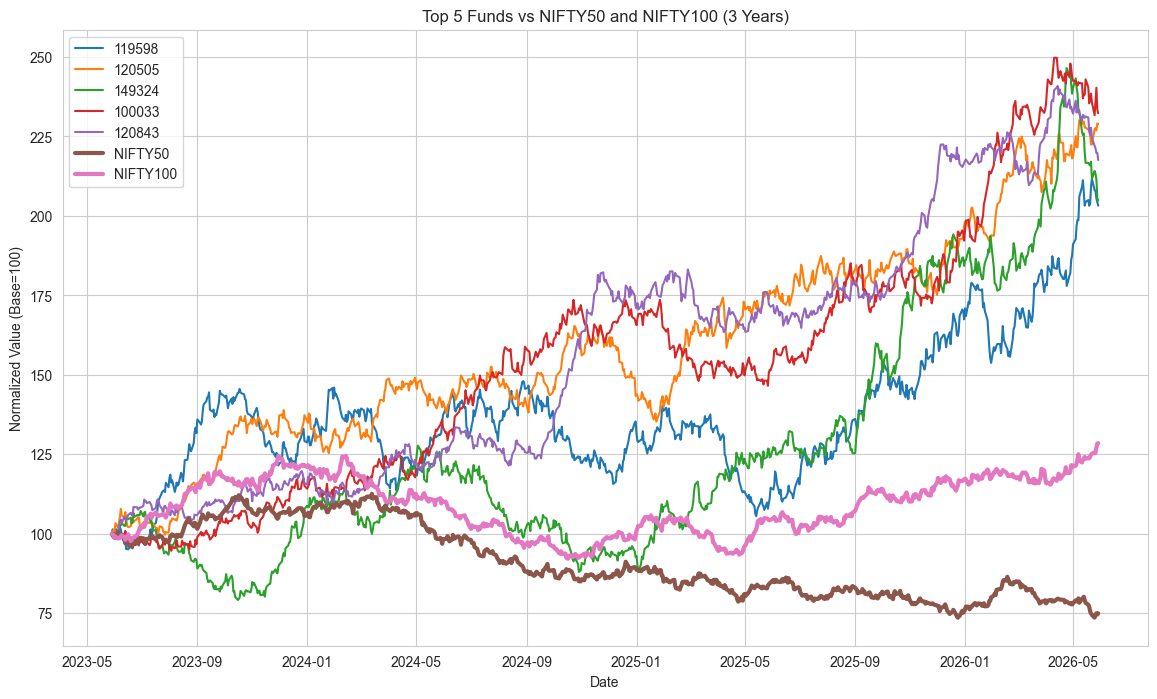

benchmark_comparison.png saved


In [351]:
import pandas as pd
import matplotlib.pyplot as plt

top5_codes = [
    119598,
    120505,
    149324,
    100033,
    120843
]

latest_date = nav["date"].max()
start_date = latest_date - pd.DateOffset(years=3)

nav_3y = nav[
    (nav["date"] >= start_date) &
    (nav["amfi_code"].isin(top5_codes))
].copy()

nav_3y["normalized_nav"] = (
    nav_3y.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50 = nifty50[nifty50["date"] >= start_date]
nifty100 = nifty100[nifty100["date"] >= start_date]

nifty50["normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0] * 100
)

nifty100["normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0] * 100
)

plt.figure(figsize=(14,8))

for code in top5_codes:
    temp = nav_3y[
        nav_3y["amfi_code"] == code
    ]
    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=str(code)
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 and NIFTY100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base=100)")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("benchmark_comparison.png saved")

In [352]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'benchmark_comparison.png',
 'data_dictionary.md',
 'data_quality_summary.txt',
 'fund_scorecard.csv',
 'max_drawdown.csv',
 'sharpe_ratio_rankings.csv',
 'sortino_ratio_rankings.csv',
 'tracking_error.csv']